# Inception — Sleep Stage Classification · Модель (sklearn)

Второй ноутбук: здесь живёт цикл **обучение → кросс-валидация → submission**.
EDA уже сделана в `01_eda.ipynb`.

**Стратегия:**
1. Базовые линии: «самый частый класс» и логистическая регрессия.
2. Умная импутация `eog_burst_index` (раздел 2b) вместо заполнения нулём.
3. Деревья: RandomForest, ExtraTrees, HistGradientBoosting.
4. Честная оценка через кросс-валидацию (StratifiedKFold, 5 фолдов, accuracy).
5. Ансамбль (soft voting) лучших моделей.
6. Обучение на всём train → предсказание test → `submission.csv`.

Бустинги (LightGBM/XGBoost) добавим позже отдельным шагом.

## 1. Импорты и загрузка

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings; warnings.filterwarnings("ignore")

from sklearn.model_selection import cross_val_score, StratifiedKFold, train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (RandomForestClassifier, ExtraTreesClassifier,
                              HistGradientBoostingClassifier, VotingClassifier)
from sklearn.pipeline import Pipeline
from sklearn.experimental import enable_iterative_imputer   # нужно ДО импорта IterativeImputer
from sklearn.impute import IterativeImputer, SimpleImputer, KNNImputer
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, r2_score

sns.set_theme(style="whitegrid")

train = pd.read_csv("data/train.csv")
test  = pd.read_csv("data/test.csv")

print("train:", train.shape, " test:", test.shape)
train.head()

train: (9000, 23)  test: (5000, 22)


,id,eeg_delta_power,eeg_theta_power,eeg_alpha_power,eeg_sigma_power,eeg_beta_power,eeg_gamma_power,eeg_slow_osc_power,eeg_spectral_entropy,eeg_spindle_density,...,eog_movement_density,eog_amplitude,heart_rate_mean,heart_rate_variability,respiration_rate,respiration_variability,spo2_mean,body_movement_index,eog_burst_index,sleep_stage
0,0,-1.51474,1.40728,10.33510,-1.61350,3.73081,0.99850,1.85689,-3.24253,-1.27096,...,2.65567,1.98733,1.60184,-2.49794,-0.59521,1.71154,1.93342,1.57365,-1.36230,1
1,1,-0.28998,0.89706,1.62494,2.41580,-2.70265,-0.10131,-1.68955,0.01442,-2.87943,...,4.36423,0.09942,3.38567,-0.56386,2.16016,-4.32301,1.07270,-2.43903,-0.37271,2
2,2,3.35435,0.32987,-5.41547,2.38680,-2.90584,-2.93372,-3.11713,-0.04647,1.61782,...,-3.87561,-0.87681,-2.84480,5.08383,-4.60411,0.37967,-2.06913,2.67324,NaN,3
3,3,-1.44917,-0.04374,1.71560,-1.27770,-0.19007,2.21826,1.69621,0.39756,0.00534,...,1.41415,0.39275,0.55060,-2.12910,2.32790,0.78319,0.98233,1.53824,-0.25040,1
4,4,1.35898,-2.36720,-7.40779,5.31815,-2.55954,-5.13284,-5.26634,1.73985,1.04618,...,-0.55616,0.86588,-1.96343,4.30036,0.22130,-1.44020,1.35760,-3.07701,-1.04947,3


## 2. Подготовка признаков

In [2]:
# 21 признак = все колонки, кроме служебных id и target
features = [c for c in train.columns if c not in ("id", "sleep_stage")]

X = train[features].copy()
y = train["sleep_stage"].copy()
X_test = test[features].copy()

# ВАЖНО: пропуски в eog_burst_index НЕ заполняем здесь руками.
# Их закроет импутер ВНУТРИ пайплайна (раздел 2b) — так не будет утечки
# и тот же импутер применится к test.
print("Признаков:", len(features))
print("Пропусков в eog_burst_index — train:", X["eog_burst_index"].isna().sum(),
      " test:", X_test["eog_burst_index"].isna().sum())

Признаков: 21
Пропусков в eog_burst_index — train: 4501  test: 2477


## 2b. Почему не заполнять нулём — умная импутация `eog_burst_index`

В `eog_burst_index` ~50% пропусков, но это **важный признак**. Простой `fillna(0)`
ставит константу половине строк и стирает сигнал. Проверим, можно ли восстановить
значение по остальным признакам.

In [3]:
# (1) Предсказуем ли eog_burst_index по другим 20 признакам?
#     Прячем 30% реальных значений, восстанавливаем, сравниваем с настоящими.
col = "eog_burst_index"
others = [c for c in features if c != col]

obs_idx = X.index[X[col].notna()]
rng = np.random.RandomState(0)
hidden = rng.choice(obs_idx, size=int(len(obs_idx) * 0.3), replace=False)
true_vals = X.loc[hidden, col].copy()

X_masked = X.copy(); X_masked.loc[hidden, col] = np.nan
imp_demo = IterativeImputer(random_state=42, max_iter=10)
filled = pd.DataFrame(imp_demo.fit_transform(X_masked), columns=features, index=X.index)
pred_vals = filled.loc[hidden, col]

print(f"R2 восстановления спрятанных значений: {r2_score(true_vals, pred_vals):.3f}")
print(f"Средняя ошибка (MAE): {np.abs(true_vals - pred_vals).mean():.3f}  (std признака {true_vals.std():.2f})")

R2 восстановления спрятанных значений: 0.871
Средняя ошибка (MAE): 0.298  (std признака 1.04)


In [4]:
# (2) Сохраняется ли связь со sleep_stage? Импьютер НЕ видит класс!
#     Сравним среднее eog по стадиям сна: реальные vs восстановленные значения.
miss_idx = X.index[X[col].isna()]
imp_full = IterativeImputer(random_state=42, max_iter=10)
filled_full = pd.DataFrame(imp_full.fit_transform(X), columns=features, index=X.index)
imp_vals = filled_full.loc[miss_idx, col]

by_obs = X.loc[X[col].notna()].groupby(y[X[col].notna()])[col].mean()
by_imp = imp_vals.groupby(y.loc[miss_idx]).mean()
compare = pd.DataFrame({"реальные": by_obs, "восстановленные": by_imp}).round(3)
compare.index.name = "sleep_stage"
print(compare)

             реальные  восстановленные
sleep_stage                           
0               0.987            0.945
1              -0.647           -0.602
2               0.480            0.407
3              -0.706           -0.631


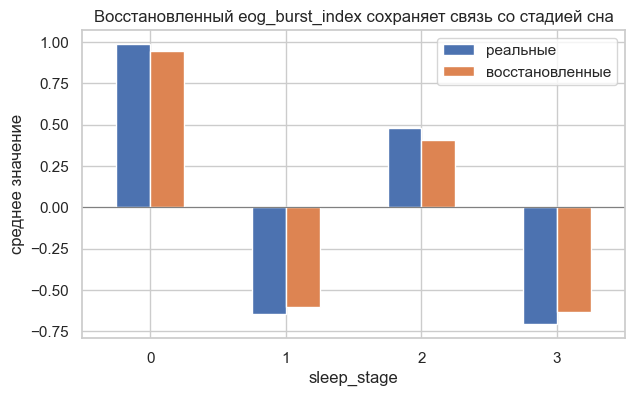

In [5]:
# наглядно: восстановленные средние повторяют паттерн реальных
compare.plot(kind="bar", figsize=(7, 4))
plt.title("Восстановленный eog_burst_index сохраняет связь со стадией сна")
plt.ylabel("среднее значение"); plt.xticks(rotation=0)
plt.axhline(0, color="gray", lw=0.8)
plt.show()

**Вывод.** Значение восстанавливается с R² ≈ 0.87 и сохраняет ту же зависимость
от стадии сна, что и реальные данные (хотя импьютер класс не видел). Поэтому вместо
`fillna(0)` используем `IterativeImputer` — и обязательно **внутри пайплайна**,
чтобы импутер обучался только на train-фолде (без утечки).

In [6]:
# единая схема кросс-валидации + хелпер: импутер ВНУТРИ пайплайна
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def make_pipe(model):
    """Импутер + модель. Импутер учится только на train-фолде -> нет утечки."""
    return Pipeline([
        ("imputer", IterativeImputer(random_state=42, max_iter=10)),
        ("model", model),
    ])

def cv_accuracy(model):
    """Средняя accuracy по 5 фолдам (модель оборачивается в пайплайн)."""
    scores = cross_val_score(make_pipe(model), X, y, cv=cv, scoring="accuracy", n_jobs=-1)
    return scores.mean(), scores.std()

results = {}

In [7]:
# быстрая проверка: разные импутеры под одной моделью (HGB)
hgb_base = HistGradientBoostingClassifier(max_iter=600, learning_rate=0.05,
            max_leaf_nodes=31, l2_regularization=1.0, early_stopping=True, random_state=42)

imputers = {
    "zero":             SimpleImputer(strategy="constant", fill_value=0),
    "median":           SimpleImputer(strategy="median"),
    "KNN(10)":          KNNImputer(n_neighbors=10),
    "IterativeImputer": IterativeImputer(random_state=42, max_iter=10),
}
imp_scores = {}
for name, imputer in imputers.items():
    pipe = Pipeline([("imputer", imputer), ("model", hgb_base)])
    imp_scores[name] = cross_val_score(pipe, X, y, cv=cv, scoring="accuracy", n_jobs=-1).mean()
pd.Series(imp_scores).round(4).sort_values(ascending=False).rename("CV accuracy")

IterativeImputer    0.8298
KNN(10)             0.8167
zero                0.8154
median              0.8146
Name: CV accuracy, dtype: float64

In [18]:
results

{'dummy': np.float64(0.2713333333333333),
 'logreg': np.float64(0.745),
 'random_forest': np.float64(0.7986666666666666),
 'extra_trees': np.float64(0.7994444444444444),
 'hgb_default': np.float64(0.8124444444444444),
 'hgb_tuned': np.float64(0.8154444444444444),
 'ensemble': np.float64(0.8184444444444445)}

## 3. Базовые линии

In [8]:
# 3.1 «Самый частый класс» — нижняя граница
m, s = cv_accuracy(DummyClassifier(strategy="most_frequent"))
results["dummy"] = m
print(f"Dummy (most_frequent): {m:.4f} +/- {s:.4f}")

Dummy (most_frequent): 0.2713 +/- 0.0003


In [9]:
# 3.2 Логистическая регрессия — простая линейная модель
m, s = cv_accuracy(LogisticRegression(max_iter=2000))
results["logreg"] = m
print(f"LogisticRegression:    {m:.4f} +/- {s:.4f}")

LogisticRegression:    0.7490 +/- 0.0104


Логистическая регрессия заметно лучше «угадывания» — значит в признаках есть сигнал.
Но граница между классами не линейная, поэтому пробуем деревья.

## 4. Деревья и градиентный бустинг

In [10]:
m, s = cv_accuracy(RandomForestClassifier(n_estimators=400, n_jobs=-1, random_state=42))
results["random_forest"] = m
print(f"RandomForest:          {m:.4f} +/- {s:.4f}")

RandomForest:          0.8259 +/- 0.0089


In [11]:
m, s = cv_accuracy(ExtraTreesClassifier(n_estimators=600, n_jobs=-1, random_state=42))
results["extra_trees"] = m
print(f"ExtraTrees:            {m:.4f} +/- {s:.4f}")

ExtraTrees:            0.8268 +/- 0.0051


In [12]:
m, s = cv_accuracy(HistGradientBoostingClassifier(random_state=42))
results["hgb_default"] = m
print(f"HistGradientBoosting:  {m:.4f} +/- {s:.4f}")

HistGradientBoosting:  0.8286 +/- 0.0112


HistGradientBoosting — лучший из «коробочных». Немного его настроим:
больше деревьев + меньше learning_rate + регуляризация и ранняя остановка.

In [13]:
hgb = HistGradientBoostingClassifier(
    max_iter=600,            # больше итераций (деревьев)
    learning_rate=0.05,      # мелкий шаг -> аккуратнее обучение
    max_leaf_nodes=31,       # сложность каждого дерева
    l2_regularization=1.0,   # регуляризация против переобучения
    early_stopping=True,     # сам остановится, когда перестанет улучшаться
    random_state=42,
)
m, s = cv_accuracy(hgb)
results["hgb_tuned"] = m
print(f"HGB (tuned):           {m:.4f} +/- {s:.4f}")

HGB (tuned):           0.8298 +/- 0.0076


## 5. Ансамбль — soft voting

In [14]:
# объединяем лучшие модели: каждая голосует вероятностями, берём среднее
ensemble = VotingClassifier(
    estimators=[
        ("hgb", hgb),
        ("et",  ExtraTreesClassifier(n_estimators=600, n_jobs=-1, random_state=42)),
        ("rf",  RandomForestClassifier(n_estimators=400, n_jobs=-1, random_state=42)),
    ],
    voting="soft", n_jobs=-1,
)
m, s = cv_accuracy(ensemble)
results["ensemble"] = m
print(f"Ensemble (soft vote):  {m:.4f} +/- {s:.4f}")

Ensemble (soft vote):  0.8343 +/- 0.0083


## 6. Сравнение моделей

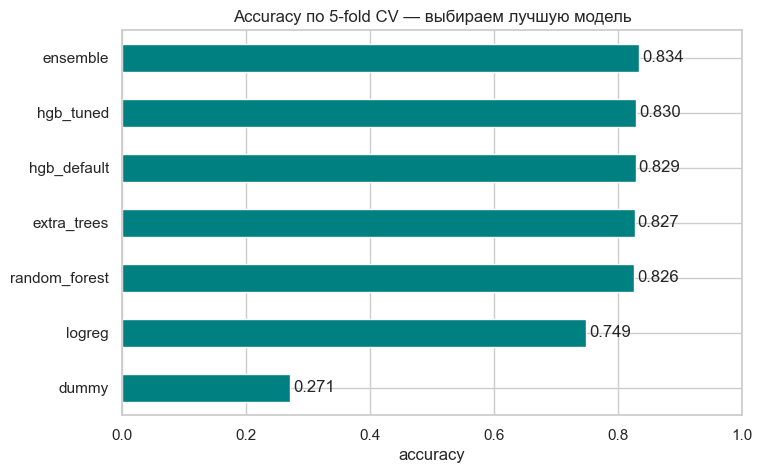

ensemble         0.834333
hgb_tuned        0.829778
hgb_default      0.828556
extra_trees      0.826778
random_forest    0.825889
logreg           0.749000
dummy            0.271333
dtype: float64

In [15]:
res = pd.Series(results).sort_values()
plt.figure(figsize=(8, 5))
res.plot(kind="barh", color="teal")
plt.title("Accuracy по 5-fold CV — выбираем лучшую модель")
plt.xlabel("accuracy"); plt.xlim(0, 1)
for i, v in enumerate(res.values):
    plt.text(v + 0.005, i, f"{v:.3f}", va="center")
plt.show()
res.sort_values(ascending=False)

## 7. Диагностика лучшей модели

In [16]:
# отложенная выборка + тот же пайплайн (импутер учится только на train-части)
X_tr, X_val, y_tr, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
best = make_pipe(ensemble).fit(X_tr, y_tr)
pred_val = best.predict(X_val)
print(f"Holdout accuracy: {accuracy_score(y_val, pred_val):.4f}\n")
print(classification_report(y_val, pred_val))

Holdout accuracy: 0.8389

              precision    recall  f1-score   support

           0       0.86      0.85      0.86       400
           1       0.85      0.85      0.85       489
           2       0.80      0.81      0.81       447
           3       0.85      0.83      0.84       464

    accuracy                           0.84      1800
   macro avg       0.84      0.84      0.84      1800
weighted avg       0.84      0.84      0.84      1800



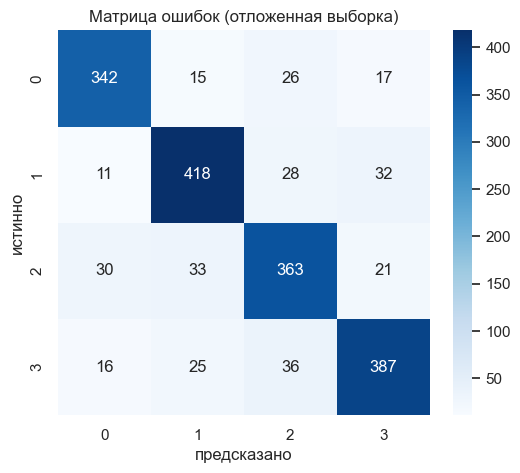

In [17]:
cm = confusion_matrix(y_val, pred_val)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=[0,1,2,3], yticklabels=[0,1,2,3])
plt.title("Матрица ошибок (отложенная выборка)")
plt.xlabel("предсказано"); plt.ylabel("истинно")
plt.show()

## 8. Финальное обучение и submission

In [18]:
best_name = max(results, key=results.get)
print("Лучшая модель по CV:", best_name, f"({results[best_name]:.4f})")

# финальная модель = импутер + ансамбль, обучаем на ВСЁМ train.
# импутер учится на train и тем же объектом заполняет пропуски в test (без утечки).
final_model = make_pipe(VotingClassifier(
    estimators=[
        ("hgb", HistGradientBoostingClassifier(max_iter=600, learning_rate=0.05,
                 max_leaf_nodes=31, l2_regularization=1.0, early_stopping=True, random_state=42)),
        ("et",  ExtraTreesClassifier(n_estimators=600, n_jobs=-1, random_state=42)),
        ("rf",  RandomForestClassifier(n_estimators=400, n_jobs=-1, random_state=42)),
    ],
    voting="soft", n_jobs=-1,
)).fit(X, y)

test_pred = final_model.predict(X_test)
print("Предсказано меток:", len(test_pred))

Лучшая модель по CV: ensemble (0.8343)


Предсказано меток: 5000


In [19]:
submission = pd.DataFrame({"id": test["id"], "sleep_stage": test_pred})

# проверки перед сохранением
assert list(submission.columns) == ["id", "sleep_stage"]
assert len(submission) == len(test) == 5000
assert submission["sleep_stage"].isin([0, 1, 2, 3]).all()

submission.to_csv("submission.csv", index=False)
print("Сохранено: submission.csv")
print(submission["sleep_stage"].value_counts().sort_index())
submission.head()

Сохранено: submission.csv
sleep_stage
0    1120
1    1295
2    1291
3    1294
Name: count, dtype: int64


,id,sleep_stage
0,9000,3
1,9001,3
2,9002,1
3,9003,2
4,9004,3


## 9. Отправка на Kaggle

Файл `submission.csv` готов — **заливаю на Kaggle вручную** через сайт
(Competitions → inception → Submit Predictions).

**Дальше для улучшения:** добавить LightGBM / XGBoost в ансамбль, подбор
гиперпараметров (Optuna), out-of-fold стэкинг.